<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/Anomaly%20Detection%20in%20Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection in Images using Convolutional Autoencoders

This notebook demonstrates how to build an autoencoder to detect defects or abnormal patterns. We will:
1. Build a Convolutional Autoencoder.
2. Train it on 'normal' data.
3. Identify anomalies based on reconstruction loss.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# For demonstration, we will use MNIST but treat one class as 'normal' and others as 'anomalies'
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape for CNN
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Let's say '0' is our normal product, and other digits are 'defects'
normal_data = x_train[y_train == 0]
anomalous_data = x_test[y_test != 0][:1000]

print(f"Normal samples for training: {len(normal_data)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Normal samples for training: 5923


In [2]:
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Input(shape=(28, 28, 1)),
      layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
      layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2)])

    self.decoder = tf.keras.Sequential([
      layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()
autoencoder.compile(optimizer='adam', loss='mse')

In [3]:
# Train only on normal data
history = autoencoder.fit(normal_data, normal_data,
                epochs=10,
                batch_size=128,
                validation_split=0.1,
                verbose=1)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.1931 - val_loss: 0.1305
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0890 - val_loss: 0.0623
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0427 - val_loss: 0.0201
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0138 - val_loss: 0.0103
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0096 - val_loss: 0.0086
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0083 - val_loss: 0.0075
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0074 - val_loss: 0.0068
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0056 - val_loss: 0.0052


186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Reconstruction error threshold: 0.03574797511100769
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


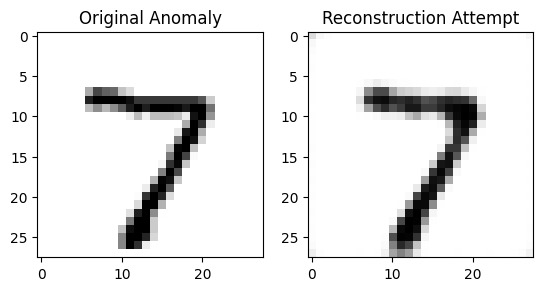

In [4]:
# Calculate reconstruction error for normal vs anomalous
reconstructions = autoencoder.predict(normal_data)
train_loss = tf.keras.losses.mae(reconstructions, normal_data)
train_loss = np.mean(train_loss, axis=(1,2))

# Set threshold (e.g., mean + 2 std deviations)
threshold = np.mean(train_loss) + 2 * np.std(train_loss)

print(f"Reconstruction error threshold: {threshold}")

# Visualize a test case
reconstructed_anom = autoencoder.predict(anomalous_data[:1])
plt.subplot(1,2,1)
plt.title("Original Anomaly")
plt.imshow(anomalous_data[0].reshape(28,28), cmap='binary')
plt.subplot(1,2,2)
plt.title("Reconstruction Attempt")
plt.imshow(reconstructed_anom[0].reshape(28,28), cmap='binary')
plt.show()

## Model Evaluation
Now we evaluate the precision of our anomaly detector by checking the classification accuracy for both normal samples and anomalous 'defects'.

In [7]:
def predict_anomaly(model, data, threshold):
  reconstructions = model.predict(data, verbose=0)
  # Use Mean Absolute Error (MAE) for reconstruction loss
  loss = tf.keras.losses.mae(reconstructions, data)
  loss = np.mean(loss, axis=(1,2))
  return loss < threshold, loss

# Evaluate on a subset of data
preds_normal, _ = predict_anomaly(autoencoder, normal_data[:500], threshold)
preds_anom, _ = predict_anomaly(autoencoder, anomalous_data[:500], threshold)

print(f"Normal images correctly identified: {np.sum(preds_normal)} / 500")
print(f"Anomalous images correctly flagged: {np.sum(~preds_anom)} / 500")

Normal images correctly identified: 478 / 500
Anomalous images correctly flagged: 83 / 500


## Performance Evaluation
Finally, let's verify the model's performance by checking how many samples from both the normal and anomalous sets are correctly classified.

In [6]:
def predict_anomaly(model, data, threshold):
  reconstructions = model.predict(data, verbose=0)
  loss = tf.keras.losses.mae(reconstructions, data)
  loss = np.mean(loss, axis=(1,2))
  return loss < threshold, loss

# Test on a subset
preds_normal, _ = predict_anomaly(autoencoder, normal_data[:500], threshold)
preds_anom, _ = predict_anomaly(autoencoder, anomalous_data[:500], threshold)

print(f"Normal images correctly identified: {np.sum(preds_normal)} / 500")
print(f"Anomalous images correctly flagged: {np.sum(~preds_anom)} / 500")

Normal images correctly identified: 478 / 500
Anomalous images correctly flagged: 83 / 500


## Evaluation
Finally, let's see how many normal images vs anomalous images we correctly classify using our threshold.

In [5]:
def predict_anomaly(model, data, threshold):
  reconstructions = model.predict(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  loss = np.mean(loss, axis=(1,2))
  return tf.math.less(loss, threshold), loss

preds_normal, _ = predict_anomaly(autoencoder, normal_data[:500], threshold)
preds_anom, _ = predict_anomaly(autoencoder, anomalous_data[:500], threshold)

print(f"Normal images correctly identified: {np.sum(preds_normal)} / 500")
print(f"Anomalous images correctly flagged: {np.sum(~preds_anom)} / 500")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Normal images correctly identified: 478 / 500
Anomalous images correctly flagged: 83 / 500
